## In this notebook we will:
- find the leak. spoiler it is the row order!
- clear up the leak
- figure out the leak pattern in test data
- apply the leak to improve prediction
- check if the model explots leak indirectly

for competition https://zindi.africa/competitions/inundata-mapping-floods-in-south-africa

The simple usage of the leak result in 0.0003 reduction of logloss

### Find the leak

Leak is the row order!

In [1]:
import pandas as pd

In [2]:
train = pd.read_csv('/raid/ml/flood/Train.csv')
train.head()

,event_id,precipitation,label
0,id_spictby0jfsb_X_0,0.000000,0
1,id_spictby0jfsb_X_1,0.095438,0
2,id_spictby0jfsb_X_2,1.949560,0
3,id_spictby0jfsb_X_3,3.232160,0
4,id_spictby0jfsb_X_4,0.000000,0


<Axes: >

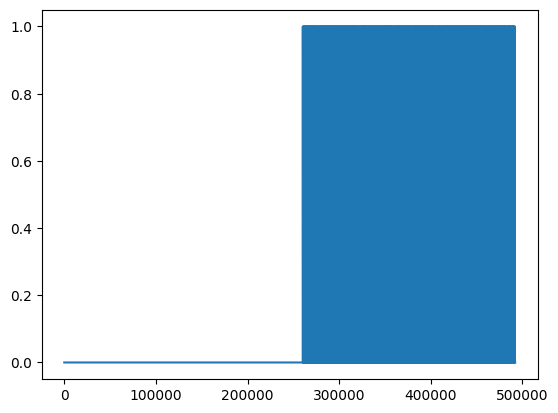

In [3]:
train.label.plot()

### Clear up the leak

In [4]:
train.label.describe()

count    492020.000000
mean          0.000646
std           0.025415
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: label, dtype: float64

In [5]:
train['location'] = train.event_id.apply(lambda x: x.split('_')[1])
train['day'] = train.event_id.apply(lambda x: x.split('_')[-1]).astype(int)
train.head()

,event_id,precipitation,label,location,day
0,id_spictby0jfsb_X_0,0.000000,0,spictby0jfsb,0
1,id_spictby0jfsb_X_1,0.095438,0,spictby0jfsb,1
2,id_spictby0jfsb_X_2,1.949560,0,spictby0jfsb,2
3,id_spictby0jfsb_X_3,3.232160,0,spictby0jfsb,3
4,id_spictby0jfsb_X_4,0.000000,0,spictby0jfsb,4


In [6]:
train.day.value_counts()

day
729    674
0      674
1      674
2      674
3      674
      ... 
14     674
13     674
12     674
11     674
10     674
Name: count, Length: 730, dtype: int64

In [7]:
train.location.unique().shape

(674,)

In [8]:
train_label_sum_df = train.groupby('location')['label'].sum().reset_index().rename(columns={'label':'label_sum'})
train_label_sum_df.head()

,location,label_sum
0,05v6zjuaf300,1
1,06zma02zeea7,0
2,08w2po0cz63y,0
3,092vetuky9ku,0
4,0987b1h04r48,1


In [9]:
# restore the original row order
train_location_row_order = train[['location']].drop_duplicates('location')
train_label_sum_df = train_label_sum_df.merge(train_location_row_order, on='location', how='right')
train_label_sum_df.head()

,location,label_sum
0,spictby0jfsb,0
1,rwieomgk4tiq,0
2,ubquyb8juwfx,0
3,c23jvpv4bjzk,0
4,oygioxfn3vgh,0


<Axes: >

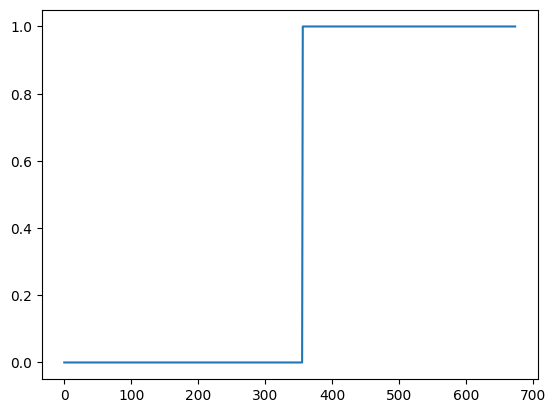

In [10]:
train_label_sum_df.label_sum.plot()

In [11]:
train_label_sum_df.label_sum.value_counts()

label_sum
0    356
1    318
Name: count, dtype: int64

In [12]:
FLOOD_RATIO = 318/train_label_sum_df.shape[0]
FLOOD_RATIO

0.47181008902077154

#### In summary, the leak is the row order.
- The first 318 locations in Train.csv are locations with flood.
- The rest 356 locations in Train.csv are locations without flood.

given the leak and the fact that there can be at most one flood day for each location, we can use the leak in the following way:
- for locations with flood, normalize the probabilty of each day by the sum of probabilities of 730 days.
- for location without flood, set the all probabilties to 0

### figure out the leak pattern in test data
So how can we confirm the test data has the same leak?

In [13]:
# we can look at any submission we have
test = pd.read_csv('/raid/ml/flood/Test.csv')
sub = pd.read_csv('../scripts/subs/lb_0.002523834.csv') # need one of the submission file
test = test.merge(sub,on='event_id',how='left')
test.head()

,event_id,precipitation,label
0,id_j7b6sokflo4k_X_0,0.00000,3.100000e-09
1,id_j7b6sokflo4k_X_1,3.01864,3.400000e-09
2,id_j7b6sokflo4k_X_2,0.00000,3.400000e-09
3,id_j7b6sokflo4k_X_3,16.61520,3.400000e-09
4,id_j7b6sokflo4k_X_4,2.56706,3.400000e-09


<Axes: >

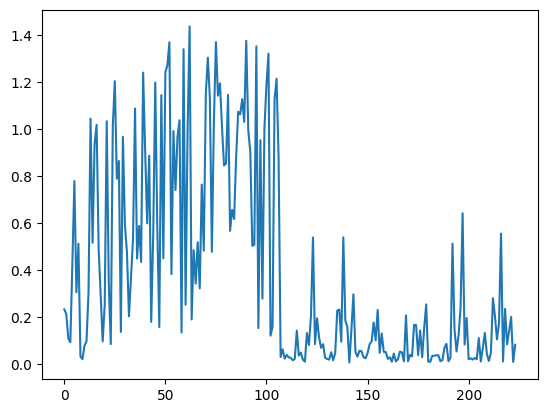

In [14]:
test['location'] = test.event_id.apply(lambda x: x.split('_')[1])
test_location_row_order = test[['location']].drop_duplicates('location')
test_label_sum_df= test.groupby('location')['label'].sum().reset_index().rename(columns={'label':'label_sum'})
test_label_sum_df = test_label_sum_df.merge(test_location_row_order, on='location', how='right')
test_label_sum_df.label_sum.plot()

So visually,
- in training data, the FLOOD_RATIO locations in the end are locations with flood
- in test data, the first FLOOD_RATIO locations in the beginning are locations with flood

To confirm it is true, we need to apply the leak and submit to leaderboard

### Apply the leak to improve prediction
- for locations with flood, normalize the probabilty of each day by the sum of probabilities of 730 days.
- for location without flood, set the all probabilties to 0

In [15]:
import pandas as pd
from sklearn.metrics import log_loss
def apply_leak(oringal_data_path, submission_path):
    # orgintal_data_path: the path of Train.csv or Test.csv
    # submission_path: the path of submission or cv predictions
    assert oringal_data_path.endswith(('Train.csv', 'Test.csv'))
    df = pd.read_csv(oringal_data_path)
    if oringal_data_path.endswith('Train.csv'):
        # the column 'label' in submission means prediction for the ground truth label
        # rename 'label' column in Train.csv to avoid confusion
        df = df.rename(columns={'label':'ground_truth'})
        is_train = True
    else:
        is_train = False
    df['location'] = df.event_id.apply(lambda x: x.split('_')[1])
    sub = pd.read_csv(submission_path)
    df = df.merge(sub,on='event_id',how='left')
    if is_train:
        loss = log_loss(df['ground_truth'], df['label'])
        print(f'Before applying leak, log loss: {loss:.5f}')
    df['sum_label'] = df.groupby('location')['label'].transform('sum')
    
    df_location_row_order = df[['location']].drop_duplicates('location')

    num_locations = len(df_location_row_order)
    n = int(num_locations*FLOOD_RATIO)
    if is_train:
        # the second FLOOD_RATIO locations are locations with flood
        flood_locations = df_location_row_order.location.values[-n:]
    else:
        # the first FLOOD_RATIO locations are locations with flood
        flood_locations = df_location_row_order.location.values[:n]

    mask = df.location.isin(flood_locations)
    df.loc[mask, 'label'] = df.loc[mask, 'label']/df.loc[mask, 'sum_label']
    df.loc[~mask, 'label'] = 0
    if is_train:
        loss = log_loss(df['ground_truth'], df['label'])
        print(f'After applying leak, log loss: {loss:.5f}')
    return df[['event_id','label']]
    

In [16]:
cv = apply_leak(oringal_data_path='/raid/ml/flood/Train.csv', 
                submission_path='../scripts/subs/cv_lb_0.002523834.csv')

Before applying leak, log loss: 0.00245
After applying leak, log loss: 0.00214


In [17]:
sub = apply_leak(oringal_data_path='/raid/ml/flood/Test.csv', 
                submission_path='../scripts/subs/lb_0.002523834.csv')
sub.to_csv('sub_leak.csv', index=False, float_format='%.10f')

- before leak, lb 0.002523834
- after leak, lb 0.002262368

### Check  visually if your submission has leak.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
def check_leak(oringal_data_path, submission_path):
    # orgintal_data_path: the path of Test.csv
    # submission_path: the path of submission csv
    assert oringal_data_path.endswith('Test.csv')
    df = pd.read_csv(oringal_data_path)
    df['location'] = df.event_id.apply(lambda x: x.split('_')[1])
    sub = pd.read_csv(submission_path)
    df = df.merge(sub,on='event_id',how='left')

    df['sum_label'] = df.groupby('location')['label'].transform('sum')
    df = df.drop_duplicates('location')
    df.sum_label.plot(title='')
    plt.show()

A leak free submisison should be noisy with peaks and valleys


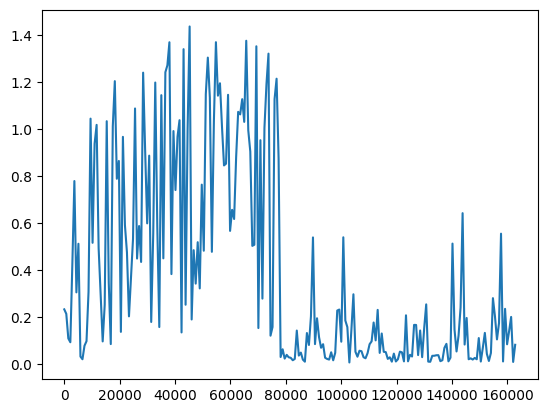

In [19]:
print('A leak free submisison should be noisy with peaks and valleys')
check_leak(oringal_data_path='/raid/ml/flood/Test.csv', 
           submission_path='../scripts/subs/lb_0.002523834.csv')

A full-blown leak submission is a clear step down pattern.


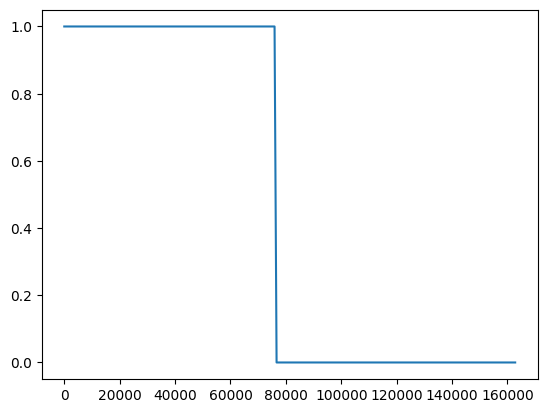

In [20]:
print('A full-blown leak submission is a clear step down pattern.')
check_leak(oringal_data_path='/raid/ml/flood/Test.csv', 
           submission_path='sub_leak.csv')

If your model indirectly used row order as a feature, you can see patterns in between.